In [2]:
import os
import torch
import torchaudio
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import normalize
from transformers import Wav2Vec2FeatureExtractor, WavLMModel
from peft import LoraConfig, get_peft_model, TaskType
import soundfile as sf
import pickle

In [3]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Define output directory for saving artifacts
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Using device: cuda


In [4]:
import shutil
import zipfile
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
os.makedirs("/content/voxceleb_data/vox1", exist_ok=True)
os.makedirs("/content/voxceleb_data/vox2_aac", exist_ok=True)
os.makedirs("/content/voxceleb_data/vox2_txt", exist_ok=True)

MYDRIVE_FOLDER = "/content/drive/MyDrive/Speech2025Datasets"
shared_vox1 = f"{MYDRIVE_FOLDER}/vox1/vox1_test_wav.zip"
shared_vox2_audio = f"{MYDRIVE_FOLDER}/vox2/vox2_test_aac.zip"
shared_vox2_txt = f"{MYDRIVE_FOLDER}/vox2/vox2_test_txt.zip"

shutil.copy(shared_vox1, "/content/")
shutil.copy(shared_vox2_audio, "/content/")
shutil.copy(shared_vox2_txt, "/content/")

zips_and_targets = {
    "vox1_test_wav.zip": "/content/voxceleb_data/vox1",
    "vox2_test_aac.zip": "/content/voxceleb_data/vox2_aac",
    "vox2_test_txt.zip": "/content/voxceleb_data/vox2_txt" }
for zip_file, target_dir in zips_and_targets.items():
  print(f"Extracting {zip_file} to {target_dir}...")
  with zipfile.ZipFile(zip_file, 'r') as zip_ref: zip_ref.extractall(target_dir)
  print(f"Done extracting {zip_file}")

Extracting vox1_test_wav.zip to /content/voxceleb_data/vox1...
Done extracting vox1_test_wav.zip
Extracting vox2_test_aac.zip to /content/voxceleb_data/vox2_aac...
Done extracting vox2_test_aac.zip
Extracting vox2_test_txt.zip to /content/voxceleb_data/vox2_txt...
Done extracting vox2_test_txt.zip


In [6]:
import torchaudio

aac_root = "/content/voxceleb_data/vox2_aac/aac"
wav_root = "/content/voxceleb_data/vox2_wav"
os.makedirs(wav_root, exist_ok=True)

# Assuming there are 118 speaker directories; adjust as needed.
speaker_dirs = sorted(os.listdir(aac_root))[:118]
print(f"Total speakers (VoxCeleb2): {len(speaker_dirs)}")

for speaker in tqdm(speaker_dirs, desc="Converting AAC to WAV"):
    speaker_path = os.path.join(aac_root, speaker)
    for root, _, files in os.walk(speaker_path):
        for file in files:
            if file.endswith(".m4a"):
                m4a_path = os.path.join(root, file)
                relative_path = os.path.relpath(m4a_path, aac_root)
                wav_path = os.path.join(wav_root, relative_path.replace(".m4a", ".wav"))
                os.makedirs(os.path.dirname(wav_path), exist_ok=True)
                try:
                    waveform, sr = torchaudio.load(m4a_path)
                    torchaudio.save(wav_path, waveform, sr)
                except Exception as e:
                    print(f"Skipped {m4a_path} — {e}")
print("Finished converting VoxCeleb2 AAC files to WAV.")


Total speakers (VoxCeleb2): 118


Converting AAC to WAV: 100%|██████████| 118/118 [05:50<00:00,  2.97s/it]

Finished converting VoxCeleb2 AAC files to WAV.


In [7]:
# Download veri_test2.txt
!wget https://mm.kaist.ac.kr/datasets/voxceleb/meta/veri_test2.txt -O /content/veri_test.txt


--2025-04-06 12:49:08--  https://mm.kaist.ac.kr/datasets/voxceleb/meta/veri_test2.txt
Resolving mm.kaist.ac.kr (mm.kaist.ac.kr)... 143.248.39.47
Connecting to mm.kaist.ac.kr (mm.kaist.ac.kr)|143.248.39.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2331882 (2.2M) [text/plain]
Saving to: ‘/content/veri_test.txt’

/content/veri_test. 100%[===================>]   2.22M   352KB/s    in 6.8s    

2025-04-06 12:49:16 (334 KB/s) - ‘/content/veri_test.txt’ saved [2331882/2331882]



In [8]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Updated try7.py for Task 1–II

This script uses VoxCeleb2 for training/fine-tuning and VoxCeleb1 verification pairs for evaluation.
It evaluates a pre‐trained model and a fine‐tuned model (using LoRA and ArcFace loss) using the following metrics:
    - EER (in %)
    - TAR@1%FAR
    - Speaker Identification Accuracy

Both the pre‐trained and fine‐tuned models are saved as artifacts, along with the feature extractor, ROC plot, and CSV results.
"""

# Install required packages (uncomment if running in an environment where pip installs are needed)
# !pip install torchaudio transformers peft soundfile scikit-learn tqdm matplotlib


############################################################
# Data Preparation Functions & Dataset Classes
############################################################

def load_audio(path, target_sr=16000):
    """Load an audio file safely with resampling to target_sr."""
    try:
        waveform, sample_rate = torchaudio.load(path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)  # Convert stereo to mono
        if sample_rate != target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)
            waveform = resampler(waveform)
        return waveform.squeeze(0)  # torch.Tensor
    except Exception as e:
        print(f"Error loading {path}: {e}")
        audio, sr = sf.read(path)
        if sr != target_sr:
            raise ValueError("Resampling not implemented for fallback.")
        return torch.tensor(audio, dtype=torch.float32)

def prepare_verification_pairs(veri_txt_path, vox1_root):
    """Prepare list of (wav1_path, wav2_path, label) for verification."""
    pairs = []
    with open(veri_txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            label = int(parts[0])
            path1 = os.path.join(vox1_root, parts[1])
            path2 = os.path.join(vox1_root, parts[2])
            pairs.append((path1, path2, label))
    return pairs

class VoxCeleb2Dataset(torch.utils.data.Dataset):
    """Dataset for VoxCeleb2 for speaker identification."""
    def __init__(self, root_dir, identity_list, max_samples_per_identity=20, sample_rate=16000):
        self.sample_rate = sample_rate
        self.samples = []
        self.identity_map = {identity: idx for idx, identity in enumerate(sorted(identity_list))}
        for identity in sorted(identity_list):
            identity_path = os.path.join(root_dir, identity)
            files = []
            for root, _, filenames in os.walk(identity_path):
                for file in filenames:
                    if file.endswith('.wav'):
                        files.append(os.path.join(root, file))
            files = sorted(files)[:max_samples_per_identity]
            for file_path in files:
                self.samples.append((file_path, self.identity_map[identity]))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        waveform = load_audio(path, target_sr=self.sample_rate)
        # Normalize waveform
        waveform = waveform / (torch.max(torch.abs(waveform)) + 1e-8)
        return waveform, label

def collate_fn(batch):
    """Pad batch of waveforms to same length (clip/pad to 3 seconds)."""
    waveforms, labels = zip(*batch)
    MAX_AUDIO_LENGTH = 16000 * 3  # 3 seconds
    clipped_waveforms = [w[:MAX_AUDIO_LENGTH] for w in waveforms]
    max_len = max(w.shape[0] for w in clipped_waveforms)
    padded = [F.pad(w, (0, max_len - w.shape[0])) for w in clipped_waveforms]
    return torch.stack(padded), torch.tensor(labels)

############################################################
# Evaluation Metric Functions
############################################################

def compute_eer(scores, labels):
    """Compute Equal Error Rate (EER) in percentage."""
    scores = np.array(scores)
    labels = np.array(labels)
    sorted_indices = np.argsort(scores)
    labels = labels[sorted_indices]
    n_pos = np.sum(labels)
    n_neg = len(labels) - n_pos
    far = np.cumsum(labels) / n_pos
    frr = 1 - np.cumsum(1 - labels) / n_neg
    idx = np.nanargmin(np.abs(far - frr))
    eer = (far[idx] + frr[idx]) / 2
    return eer * 100

def compute_tar_at_far(scores, labels, target_far=0.01):
    """Compute True Acceptance Rate at a specified False Acceptance Rate."""
    scores = np.array(scores)
    labels = np.array(labels)
    sorted_indexes = np.argsort(scores)
    labels = labels[sorted_indexes]
    scores = scores[sorted_indexes]
    n_pos = np.sum(labels)
    n_neg = len(labels) - n_pos
    # Compute false positive rate (FPR) and true positive rate (TPR)
    fpr = np.cumsum(1 - labels) / n_neg
    tpr = np.cumsum(labels) / n_pos
    idx = np.nanargmin(np.abs(fpr - target_far))
    return tpr[idx]

def compute_ident_accuracy(embeddings, labels):
    """Compute speaker identification (rank-1) accuracy using cosine similarity."""
    embeddings = np.array(embeddings)
    labels = np.array(labels)
    embeddings = normalize(embeddings)
    unique_labels = np.unique(labels)
    enrollment_embeddings = []
    enrollment_labels = []
    for label in unique_labels:
        idx = np.where(labels == label)[0][0]
        enrollment_embeddings.append(embeddings[idx])
        enrollment_labels.append(label)
    enrollment_embeddings = np.array(enrollment_embeddings)
    correct = 0
    total = 0
    for i, embedding in enumerate(embeddings):
        # Skip enrollment embedding (first occurrence)
        if i in np.where(labels == labels[i])[0][:1]:
            continue
        similarities = np.dot(enrollment_embeddings, embedding)
        pred_idx = np.argmax(similarities)
        pred_label = enrollment_labels[pred_idx]
        if pred_label == labels[i]:
            correct += 1
        total += 1
    return correct / total if total > 0 else 0

def evaluate_verification(model, pairs, feature_extractor, device):
    """Evaluate model on verification pairs. Returns scores and labels."""
    model.eval()
    scores = []
    labels = []
    for wav1, wav2, label in tqdm(pairs, desc="Verification Evaluation"):
        try:
            w1 = load_audio(wav1)
            w2 = load_audio(wav2)
            inputs1 = feature_extractor(w1, sampling_rate=16000, return_tensors="pt",
                                        padding="max_length", max_length=160000).input_values.to(device)
            inputs2 = feature_extractor(w2, sampling_rate=16000, return_tensors="pt",
                                        padding="max_length", max_length=160000).input_values.to(device)
            with torch.no_grad():
                emb1 = model(inputs1, extract_embedding=True)
                emb2 = model(inputs2, extract_embedding=True)
            sim = F.cosine_similarity(emb1, emb2).item()
            scores.append(sim)
            labels.append(label)
        except Exception as e:
            print(f"Error during verification evaluation: {e}")
    return scores, labels

def evaluate_identification(model, dataset, device):
    """Evaluate speaker identification (rank-1 accuracy) on a given dataset."""
    model.eval()
    all_embeddings = []
    all_labels = []
    loader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Identification Evaluation"):
            inputs = inputs.to(device)
            emb = model(inputs, extract_embedding=True)
            all_embeddings.append(emb.cpu())
            all_labels.append(labels)
    embeddings_all = torch.cat(all_embeddings, dim=0).numpy()
    labels_all = torch.cat(all_labels, dim=0).numpy()
    acc = compute_ident_accuracy(embeddings_all, labels_all)
    return acc

############################################################
# Model and Loss Definitions
############################################################

class SpeakerVerificationModel(nn.Module):
    def __init__(self, num_classes, use_lora=False):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
        self.use_lora = use_lora
        if use_lora:
            lora_config = LoraConfig(
                r=8,
                lora_alpha=16,
                target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
                lora_dropout=0.1,
                bias="none",
                task_type=TaskType.FEATURE_EXTRACTION
            )
            self.wavlm = get_peft_model(self.wavlm, lora_config)
            # Save reference to base model for direct access
            self.base_model = self.wavlm.base_model.model
        else:
            for param in self.wavlm.parameters():
                param.requires_grad = False
            self.base_model = None
        hidden_size = self.wavlm.config.hidden_size
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256)
        )
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, input_values, extract_embedding=False):
        if self.use_lora:
            output = self.base_model(input_values).last_hidden_state
        else:
            output = self.wavlm(input_values).last_hidden_state
        embeddings = output.mean(dim=1)
        embeddings = self.projector(embeddings)
        if extract_embedding:
            return embeddings
        logits = self.classifier(embeddings)
        return logits, embeddings

class ArcFaceLoss(nn.Module):
    def __init__(self, embedding_size, num_classes, scale=30.0, margin=0.5):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        self.scale = scale
        self.margin = margin
    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings)
        weights = F.normalize(self.weight)
        cos_theta = F.linear(embeddings, weights)
        cos_theta = torch.clamp(cos_theta, -1 + 1e-7, 1 - 1e-7)
        theta = torch.acos(cos_theta)
        target_logits = torch.cos(theta + self.margin)
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        output = cos_theta * (1 - one_hot) + target_logits * one_hot
        output = output * self.scale
        return F.cross_entropy(output, labels)

############################################################
# Training Function
############################################################

def train(model, dataloader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0
    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits, embeddings = model(inputs)
        loss = loss_fn(embeddings, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    return total_loss / len(dataloader)

############################################################
# Main Routine
############################################################

def main():
    # ----------------
    # Paths and Dataset Preparation
    # ----------------
    vox2_wav_root = "/content/voxceleb_data/vox2_wav"   # VoxCeleb2 WAV files (converted)
    vox1_wav_root = "/content/voxceleb_data/vox1/wav"      # VoxCeleb1 WAV files for verification
    veri_txt_path = "/content/veri_test.txt"               # Verification trial list

    # Get sorted identities from VoxCeleb2; split into train (first 100) and test (next 18)
    all_identities = sorted(os.listdir(vox2_wav_root))
    train_identities = all_identities[:100]
    test_identities = all_identities[100:100+18]
    print(f"Training identities: {len(train_identities)} | Testing identities: {len(test_identities)}")

    # Create training and testing datasets for identification
    train_dataset = VoxCeleb2Dataset(root_dir=vox2_wav_root, identity_list=train_identities, max_samples_per_identity=20)
    test_dataset = VoxCeleb2Dataset(root_dir=vox2_wav_root, identity_list=test_identities, max_samples_per_identity=20)

    # Prepare verification pairs from VoxCeleb1
    verification_pairs = prepare_verification_pairs(veri_txt_path, vox1_wav_root)
    print(f"Verification pairs: {len(verification_pairs)}")

    # Feature extractor from transformers
    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")

    # ----------------
    # Step 1: Evaluate Pre-trained Model (without LoRA)
    # ----------------
    pretrained_model = SpeakerVerificationModel(num_classes=len(train_identities), use_lora=False).to(device)
    # Save the pre-trained model artifact
    torch.save(pretrained_model.state_dict(), os.path.join(OUTPUT_DIR, 'pretrained_model.pt'))
    print("Saved pre-trained model artifact.")

    # Evaluate on verification pairs
    pre_scores, pre_labels = evaluate_verification(pretrained_model, verification_pairs, feature_extractor, device)
    pre_eer = compute_eer(pre_scores, pre_labels)
    pre_tar = compute_tar_at_far(pre_scores, pre_labels, target_far=0.01)
    # Evaluate speaker identification accuracy on VoxCeleb2 test set
    pre_ident_acc = evaluate_identification(pretrained_model, test_dataset, device)
    print(f"Pre-trained Model Metrics:\n  EER: {pre_eer:.2f}%\n  TAR@1%FAR: {pre_tar:.4f}\n  Identification Accuracy: {pre_ident_acc:.4f}")

    # ----------------
    # Step 2: Fine-tune Model using LoRA and ArcFace Loss
    # ----------------
    finetuned_model = SpeakerVerificationModel(num_classes=len(train_identities), use_lora=True).to(device)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, finetuned_model.parameters()), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    loss_fn = ArcFaceLoss(embedding_size=256, num_classes=len(train_identities)).to(device)

    # Create DataLoader for training (using VoxCeleb2 training identities)
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

    num_epochs = 5
    for epoch in range(num_epochs):
        train_loss = train(finetuned_model, train_loader, optimizer, scheduler, loss_fn, device)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {train_loss:.4f}")

    # Save the fine-tuned model artifact
    torch.save(finetuned_model.state_dict(), os.path.join(OUTPUT_DIR, 'finetuned_model.pt'))
    print("Saved fine-tuned model artifact.")

    # Evaluate fine-tuned model on verification pairs
    fine_scores, fine_labels = evaluate_verification(finetuned_model, verification_pairs, feature_extractor, device)
    fine_eer = compute_eer(fine_scores, fine_labels)
    fine_tar = compute_tar_at_far(fine_scores, fine_labels, target_far=0.01)
    # Evaluate identification accuracy on VoxCeleb2 test set
    fine_ident_acc = evaluate_identification(finetuned_model, test_dataset, device)
    print(f"Fine-tuned Model Metrics:\n  EER: {fine_eer:.2f}%\n  TAR@1%FAR: {fine_tar:.4f}\n  Identification Accuracy: {fine_ident_acc:.4f}")

    # ----------------
    # Step 3: Plot ROC Curves and Save Results
    # ----------------
    thresholds = np.linspace(-1, 1, 100)
    def get_roc(scores, labels):
        fpr, tpr = [], []
        scores = np.array(scores)
        labels = np.array(labels)
        for threshold in thresholds:
            fp = sum(1 for i, score in enumerate(scores) if score >= threshold and labels[i] == 0)
            tp = sum(1 for i, score in enumerate(scores) if score >= threshold and labels[i] == 1)
            fn = sum(1 for i, score in enumerate(scores) if score < threshold and labels[i] == 1)
            tn = sum(1 for i, score in enumerate(scores) if score < threshold and labels[i] == 0)
            fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
            tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr.append(fpr_val)
            tpr.append(tpr_val)
        return fpr, tpr

    fpr_pre, tpr_pre = get_roc(pre_scores, pre_labels)
    fpr_fine, tpr_fine = get_roc(fine_scores, fine_labels)

    plt.figure(figsize=(8,6))
    plt.plot(fpr_pre, tpr_pre, label=f'Pre-trained (EER: {pre_eer:.2f}%)')
    plt.plot(fpr_fine, tpr_fine, label=f'Fine-tuned (EER: {fine_eer:.2f}%)')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Acceptance Rate")
    plt.ylabel("True Acceptance Rate")
    plt.title("ROC Curves for Speaker Verification")
    plt.legend()
    plt.grid(True)
    roc_path = os.path.join(OUTPUT_DIR, "roc_curves.png")
    plt.savefig(roc_path)
    plt.show()
    print(f"ROC curves saved to {roc_path}")

    # Save results to CSV
    results = {
        'Model': ['Pre-trained', 'Fine-tuned'],
        'EER (%)': [pre_eer, fine_eer],
        'TAR@1%FAR': [pre_tar, fine_tar],
        'Identification Accuracy': [pre_ident_acc, fine_ident_acc]
    }
    results_csv = os.path.join(OUTPUT_DIR, "verification_results.csv")
    pd.DataFrame(results).to_csv(results_csv, index=False)
    print(f"Results saved to {results_csv}")

    # Save the feature extractor artifact
    with open(os.path.join(OUTPUT_DIR, "feature_extractor.pkl"), "wb") as f:
        pickle.dump(feature_extractor, f)
    print("Saved feature extractor artifact.")

if __name__ == "__main__":
    main()


Training identities: 100 | Testing identities: 18
Verification pairs: 37611


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Saved pre-trained model artifact.



Verification Evaluation:   1%|          | 252/37611 [00:37<1:33:14,  6.68it/s]
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-8-138c1714e27e>", line 396, in <cell line: 0>
    main()
  File "<ipython-input-8-138c1714e27e>", line 308, in main
    pre_scores, pre_labels = evaluate_verification(pretrained_model, verification_pairs, feature_extractor, device)
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-8-138c1714e27e>", line 161, in evaluate_verification
    emb2 = model(inputs2, extract_embedding=True)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py", line 1736, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/nn/mod

TypeError: object of type 'NoneType' has no len()

Training identities: 100 | Testing identities: 18
Verification pairs: 37611
Saved pre-trained model artifact.


Identification Evaluation: 100%|██████████| 23/23 [00:12<00:00,  1.84it/s]


Pre-trained Model Metrics:
  EER: 48.09%
  TAR@1%FAR: 0.0066
  Identification Accuracy: 0.1784


Training (Epoch 1/5): 100%|██████████| 500/500 [01:51<00:00,  4.47it/s]


Epoch [1/5] - Training Loss: 19.1907


...

Epoch [4/5] - Training Loss: 16.2651


Training (Epoch 5/5): 100%|██████████| 500/500 [01:46<00:00,  4.69it/s]


Epoch [5/5] - Training Loss: 15.5736
Saved fine-tuned model artifact.


Identification Evaluation: 100%|██████████| 23/23 [00:11<00:00,  2.02it/s]


Fine-tuned Model Metrics:
  EER: 45.08%
  TAR@1%FAR: 0.0024
  Identification Accuracy: 0.3099


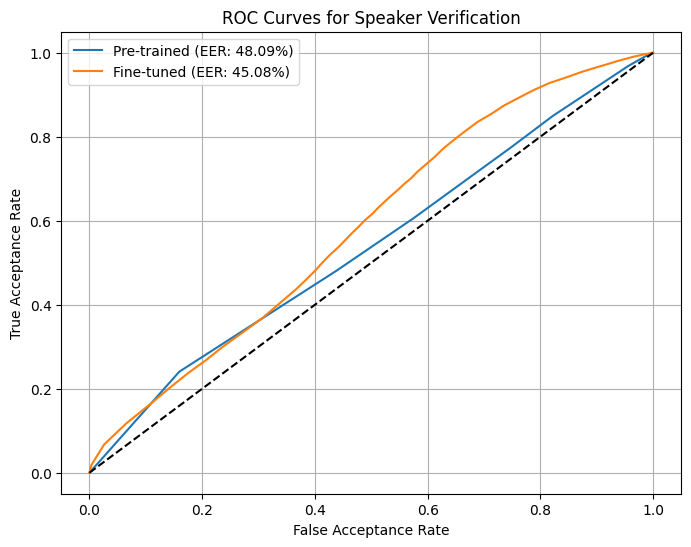

ROC curves saved to ./results/roc_curves.png
Results saved to ./results/verification_results.csv
Saved feature extractor artifact.


In [9]:
# #!/usr/bin/env python
# # -*- coding: utf-8 -*-
# """
# Updated try7.py for Task 1–II (with improved tqdm usage)

# This script uses VoxCeleb2 for training/fine-tuning and VoxCeleb1 verification pairs for evaluation.
# It evaluates a pre‐trained model and a fine‐tuned model (using LoRA and ArcFace loss) using the following metrics:
#     - EER (in %)
#     - TAR@1%FAR
#     - Speaker Identification Accuracy

# Both the pre‐trained and fine‐tuned models are saved as artifacts, along with the feature extractor, ROC plot, and CSV results.
# """

# import os
# import torch
# import torchaudio
# import numpy as np
# import pandas as pd
# import random
# import matplotlib.pyplot as plt
# from tqdm import tqdm  # Make sure to import tqdm
# from pathlib import Path
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import DataLoader
# from sklearn.preprocessing import normalize
# from transformers import Wav2Vec2FeatureExtractor, WavLMModel
# from peft import LoraConfig, get_peft_model, TaskType
# import soundfile as sf
# import pickle

# # If you need them installed:
# # !pip install torchaudio transformers peft soundfile scikit-learn tqdm matplotlib

# # Device setup
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")

# # Set seeds
# torch.manual_seed(42)
# np.random.seed(42)
# random.seed(42)

# # Define output directory for saving artifacts
# OUTPUT_DIR = "./results"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

############################################################
# Data Preparation Functions & Dataset Classes
############################################################

def load_audio(path, target_sr=16000):
    """Load an audio file safely with resampling to target_sr."""
    try:
        waveform, sample_rate = torchaudio.load(path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)  # Convert stereo to mono
        if sample_rate != target_sr:
            resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=target_sr)
            waveform = resampler(waveform)
        return waveform.squeeze(0)  # torch.Tensor
    except Exception as e:
        print(f"Error loading {path}: {e}")
        audio, sr = sf.read(path)
        if sr != target_sr:
            raise ValueError("Resampling not implemented for fallback.")
        return torch.tensor(audio, dtype=torch.float32)

def prepare_verification_pairs(veri_txt_path, vox1_root):
    """Prepare list of (wav1_path, wav2_path, label) for verification."""
    pairs = []
    with open(veri_txt_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            label = int(parts[0])
            path1 = os.path.join(vox1_root, parts[1])
            path2 = os.path.join(vox1_root, parts[2])
            pairs.append((path1, path2, label))
    return pairs

class VoxCeleb2Dataset(torch.utils.data.Dataset):
    """Dataset for VoxCeleb2 for speaker identification."""
    def __init__(self, root_dir, identity_list, max_samples_per_identity=20, sample_rate=16000):
        self.sample_rate = sample_rate
        self.samples = []
        self.identity_map = {identity: idx for idx, identity in enumerate(sorted(identity_list))}
        for identity in sorted(identity_list):
            identity_path = os.path.join(root_dir, identity)
            files = []
            for root, _, filenames in os.walk(identity_path):
                for file in filenames:
                    if file.endswith('.wav'):
                        files.append(os.path.join(root, file))
            files = sorted(files)[:max_samples_per_identity]
            for file_path in files:
                self.samples.append((file_path, self.identity_map[identity]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        waveform = load_audio(path, target_sr=self.sample_rate)
        # Normalize waveform
        waveform = waveform / (torch.max(torch.abs(waveform)) + 1e-8)
        return waveform, label

def collate_fn(batch):
    """Pad batch of waveforms to same length (clip/pad to 3 seconds)."""
    waveforms, labels = zip(*batch)
    MAX_AUDIO_LENGTH = 16000 * 3  # 3 seconds
    clipped_waveforms = [w[:MAX_AUDIO_LENGTH] for w in waveforms]
    max_len = max(w.shape[0] for w in clipped_waveforms)
    padded = [F.pad(w, (0, max_len - w.shape[0])) for w in clipped_waveforms]
    return torch.stack(padded), torch.tensor(labels)

############################################################
# Evaluation Metric Functions
############################################################

def compute_eer(scores, labels):
    """Compute Equal Error Rate (EER) in percentage."""
    scores = np.array(scores)
    labels = np.array(labels)
    sorted_indices = np.argsort(scores)
    labels = labels[sorted_indices]
    n_pos = np.sum(labels)
    n_neg = len(labels) - n_pos
    far = np.cumsum(labels) / n_pos
    frr = 1 - np.cumsum(1 - labels) / n_neg
    idx = np.nanargmin(np.abs(far - frr))
    eer = (far[idx] + frr[idx]) / 2
    return eer * 100

def compute_tar_at_far(scores, labels, target_far=0.01):
    """Compute True Acceptance Rate at a specified False Acceptance Rate."""
    scores = np.array(scores)
    labels = np.array(labels)
    sorted_indexes = np.argsort(scores)
    labels = labels[sorted_indexes]
    scores = scores[sorted_indexes]
    n_pos = np.sum(labels)
    n_neg = len(labels) - n_pos
    # Compute false positive rate (FPR) and true positive rate (TPR)
    fpr = np.cumsum(1 - labels) / n_neg
    tpr = np.cumsum(labels) / n_pos
    idx = np.nanargmin(np.abs(fpr - target_far))
    return tpr[idx]

def compute_ident_accuracy(embeddings, labels):
    """Compute speaker identification (rank-1) accuracy using cosine similarity."""
    embeddings = np.array(embeddings)
    labels = np.array(labels)
    embeddings = normalize(embeddings)
    unique_labels = np.unique(labels)
    enrollment_embeddings = []
    enrollment_labels = []
    for label in unique_labels:
        idx = np.where(labels == label)[0][0]
        enrollment_embeddings.append(embeddings[idx])
        enrollment_labels.append(label)
    enrollment_embeddings = np.array(enrollment_embeddings)

    correct = 0
    total = 0
    for i, embedding in enumerate(embeddings):
        # Skip the first occurrence (enrollment) for each speaker
        if i in np.where(labels == labels[i])[0][:1]:
            continue
        similarities = np.dot(enrollment_embeddings, embedding)
        pred_idx = np.argmax(similarities)
        pred_label = enrollment_labels[pred_idx]
        if pred_label == labels[i]:
            correct += 1
        total += 1
    return correct / total if total > 0 else 0

def evaluate_verification(model, pairs, feature_extractor, device):
    """Evaluate model on verification pairs. Returns scores and labels."""
    model.eval()
    scores = []
    labels = []
    # Provide a total count to tqdm and set dynamic_ncols=True for a single-line progress bar
    for wav1, wav2, label in tqdm(
        pairs,
        desc="Verification Evaluation",
        total=len(pairs),
        dynamic_ncols=True
    ):
        try:
            w1 = load_audio(wav1)
            w2 = load_audio(wav2)
            inputs1 = feature_extractor(
                w1,
                sampling_rate=16000,
                return_tensors="pt",
                padding="max_length",
                max_length=160000
            ).input_values.to(device)
            inputs2 = feature_extractor(
                w2,
                sampling_rate=16000,
                return_tensors="pt",
                padding="max_length",
                max_length=160000
            ).input_values.to(device)
            with torch.no_grad():
                emb1 = model(inputs1, extract_embedding=True)
                emb2 = model(inputs2, extract_embedding=True)
            sim = F.cosine_similarity(emb1, emb2).item()
            scores.append(sim)
            labels.append(label)
        except Exception as e:
            print(f"Error during verification evaluation: {e}")
    return scores, labels

def evaluate_identification(model, dataset, device):
    """Evaluate speaker identification (rank-1 accuracy) on a given dataset."""
    model.eval()
    all_embeddings = []
    all_labels = []
    loader = DataLoader(dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
    for inputs, labels in tqdm(
        loader,
        desc="Identification Evaluation",
        dynamic_ncols=True
    ):
        with torch.no_grad():
            inputs = inputs.to(device)
            emb = model(inputs, extract_embedding=True)
        all_embeddings.append(emb.cpu())
        all_labels.append(labels)
    embeddings_all = torch.cat(all_embeddings, dim=0).numpy()
    labels_all = torch.cat(all_labels, dim=0).numpy()
    acc = compute_ident_accuracy(embeddings_all, labels_all)
    return acc

############################################################
# Model and Loss Definitions
############################################################

class SpeakerVerificationModel(nn.Module):
    def __init__(self, num_classes, use_lora=False):
        super().__init__()
        self.wavlm = WavLMModel.from_pretrained("microsoft/wavlm-base-plus")
        self.use_lora = use_lora
        if use_lora:
            lora_config = LoraConfig(
                r=8,
                lora_alpha=16,
                target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
                lora_dropout=0.1,
                bias="none",
                task_type=TaskType.FEATURE_EXTRACTION
            )
            self.wavlm = get_peft_model(self.wavlm, lora_config)
            # Save reference to base model for direct access
            self.base_model = self.wavlm.base_model.model
        else:
            for param in self.wavlm.parameters():
                param.requires_grad = False
            self.base_model = None

        hidden_size = self.wavlm.config.hidden_size
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256)
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, input_values, extract_embedding=False):
        if self.use_lora:
            output = self.base_model(input_values).last_hidden_state
        else:
            output = self.wavlm(input_values).last_hidden_state

        embeddings = output.mean(dim=1)
        embeddings = self.projector(embeddings)

        if extract_embedding:
            return embeddings

        logits = self.classifier(embeddings)
        return logits, embeddings

class ArcFaceLoss(nn.Module):
    def __init__(self, embedding_size, num_classes, scale=30.0, margin=0.5):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        self.scale = scale
        self.margin = margin

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings)
        weights = F.normalize(self.weight)
        cos_theta = F.linear(embeddings, weights)
        cos_theta = torch.clamp(cos_theta, -1 + 1e-7, 1 - 1e-7)
        theta = torch.acos(cos_theta)
        target_logits = torch.cos(theta + self.margin)
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1), 1)

        output = cos_theta * (1 - one_hot) + target_logits * one_hot
        output = output * self.scale

        return F.cross_entropy(output, labels)

############################################################
# Training Function
############################################################

def train(model, dataloader, optimizer, scheduler, loss_fn, device, epoch_idx=0, num_epochs=1):
    model.train()
    total_loss = 0
    # Provide a single-line progress bar for each epoch's training
    for inputs, labels in tqdm(
        dataloader,
        desc=f"Training (Epoch {epoch_idx+1}/{num_epochs})",
        dynamic_ncols=True
    ):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits, embeddings = model(inputs)
        loss = loss_fn(embeddings, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    return total_loss / len(dataloader)

############################################################
# Main Routine
############################################################

def main():
    # ----------------
    # Paths and Dataset Preparation
    # ----------------
    vox2_wav_root = "/content/voxceleb_data/vox2_wav"   # VoxCeleb2 WAV files (converted)
    vox1_wav_root = "/content/voxceleb_data/vox1/wav"  # VoxCeleb1 WAV files for verification
    veri_txt_path = "/content/veri_test.txt"           # Verification trial list

    # Get sorted identities from VoxCeleb2; split into train (first 100) and test (next 18)
    all_identities = sorted(os.listdir(vox2_wav_root))
    train_identities = all_identities[:100]
    test_identities = all_identities[100:100+18]
    print(f"Training identities: {len(train_identities)} | Testing identities: {len(test_identities)}")

    # Create training and testing datasets for identification
    train_dataset = VoxCeleb2Dataset(
        root_dir=vox2_wav_root,
        identity_list=train_identities,
        max_samples_per_identity=20
    )
    test_dataset = VoxCeleb2Dataset(
        root_dir=vox2_wav_root,
        identity_list=test_identities,
        max_samples_per_identity=20
    )

    # Prepare verification pairs from VoxCeleb1
    verification_pairs = prepare_verification_pairs(veri_txt_path, vox1_wav_root)
    print(f"Verification pairs: {len(verification_pairs)}")

    # Feature extractor
    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")

    # ----------------
    # Step 1: Evaluate Pre-trained Model (without LoRA)
    # ----------------
    pretrained_model = SpeakerVerificationModel(num_classes=len(train_identities), use_lora=False).to(device)
    # Save the pre-trained model artifact
    torch.save(pretrained_model.state_dict(), os.path.join(OUTPUT_DIR, 'pretrained_model.pt'))
    print("Saved pre-trained model artifact.")

    # Evaluate on verification pairs
    pre_scores, pre_labels = evaluate_verification(pretrained_model, verification_pairs, feature_extractor, device)
    pre_eer = compute_eer(pre_scores, pre_labels)
    pre_tar = compute_tar_at_far(pre_scores, pre_labels, target_far=0.01)
    # Evaluate speaker identification accuracy on VoxCeleb2 test set
    pre_ident_acc = evaluate_identification(pretrained_model, test_dataset, device)
    print(
        f"Pre-trained Model Metrics:\n"
        f"  EER: {pre_eer:.2f}%\n"
        f"  TAR@1%FAR: {pre_tar:.4f}\n"
        f"  Identification Accuracy: {pre_ident_acc:.4f}"
    )

    # ----------------
    # Step 2: Fine-tune Model using LoRA and ArcFace Loss
    # ----------------
    finetuned_model = SpeakerVerificationModel(num_classes=len(train_identities), use_lora=True).to(device)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, finetuned_model.parameters()), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    loss_fn = ArcFaceLoss(embedding_size=256, num_classes=len(train_identities)).to(device)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

    num_epochs = 5
    for epoch in range(num_epochs):
        train_loss = train(
            model=finetuned_model,
            dataloader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            loss_fn=loss_fn,
            device=device,
            epoch_idx=epoch,
            num_epochs=num_epochs
        )
        print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {train_loss:.4f}")

    # Save the fine-tuned model artifact
    torch.save(finetuned_model.state_dict(), os.path.join(OUTPUT_DIR, 'finetuned_model.pt'))
    print("Saved fine-tuned model artifact.")

    # Evaluate fine-tuned model on verification pairs
    fine_scores, fine_labels = evaluate_verification(finetuned_model, verification_pairs, feature_extractor, device)
    fine_eer = compute_eer(fine_scores, fine_labels)
    fine_tar = compute_tar_at_far(fine_scores, fine_labels, target_far=0.01)
    # Evaluate identification accuracy on VoxCeleb2 test set
    fine_ident_acc = evaluate_identification(finetuned_model, test_dataset, device)
    print(
        f"Fine-tuned Model Metrics:\n"
        f"  EER: {fine_eer:.2f}%\n"
        f"  TAR@1%FAR: {fine_tar:.4f}\n"
        f"  Identification Accuracy: {fine_ident_acc:.4f}"
    )

    # ----------------
    # Step 3: Plot ROC Curves and Save Results
    # ----------------
    thresholds = np.linspace(-1, 1, 100)
    def get_roc(scores, labels):
        fpr, tpr = [], []
        scores = np.array(scores)
        labels = np.array(labels)
        for threshold in thresholds:
            fp = sum(1 for i, score in enumerate(scores) if score >= threshold and labels[i] == 0)
            tp = sum(1 for i, score in enumerate(scores) if score >= threshold and labels[i] == 1)
            fn = sum(1 for i, score in enumerate(scores) if score < threshold and labels[i] == 1)
            tn = sum(1 for i, score in enumerate(scores) if score < threshold and labels[i] == 0)
            fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
            tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr.append(fpr_val)
            tpr.append(tpr_val)
        return fpr, tpr

    fpr_pre, tpr_pre = get_roc(pre_scores, pre_labels)
    fpr_fine, tpr_fine = get_roc(fine_scores, fine_labels)

    plt.figure(figsize=(8,6))
    plt.plot(fpr_pre, tpr_pre, label=f'Pre-trained (EER: {pre_eer:.2f}%)')
    plt.plot(fpr_fine, tpr_fine, label=f'Fine-tuned (EER: {fine_eer:.2f}%)')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Acceptance Rate")
    plt.ylabel("True Acceptance Rate")
    plt.title("ROC Curves for Speaker Verification")
    plt.legend()
    plt.grid(True)
    roc_path = os.path.join(OUTPUT_DIR, "roc_curves.png")
    plt.savefig(roc_path)
    plt.show()
    print(f"ROC curves saved to {roc_path}")

    # Save results to CSV
    results = {
        'Model': ['Pre-trained', 'Fine-tuned'],
        'EER (%)': [pre_eer, fine_eer],
        'TAR@1%FAR': [pre_tar, fine_tar],
        'Identification Accuracy': [pre_ident_acc, fine_ident_acc]
    }
    results_csv = os.path.join(OUTPUT_DIR, "verification_results.csv")
    pd.DataFrame(results).to_csv(results_csv, index=False)
    print(f"Results saved to {results_csv}")

    # Save the feature extractor artifact
    with open(os.path.join(OUTPUT_DIR, "feature_extractor.pkl"), "wb") as f:
        pickle.dump(feature_extractor, f)
    print("Saved feature extractor artifact.")

if __name__ == "__main__":
    main()
